# Project 1: Exploratory Data Analysis of Historical Stock Market Data

**Student Name:** Mohammad Tamim Hamkar

## Introduction

This project explores historical stock market data to better understand stock prices, trading activity, data quality, and unusual observations. Python and Pandas will be used to clean, explore, visualize, and analyze the data before moving to more advanced analysis in future projects.

**Step 1: Import All Libraries**

In [15]:
# Import All Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Step 2: Load Both Datasets**

In [16]:
# Load the Datasets

stocks = pd.read_csv('/content/historical_stocks.csv')
stock_prices = pd.read_csv('/content/historical_stock_prices.csv')

print("Both datasets loaded successfully!")

Both datasets loaded successfully!


**Step 3: Display the First 5 Rows**

In [17]:
# Display the First 5 Rows

print("Historical Stocks Dataset:")
display(stocks.head())

print("\nHistorical Stock Prices Dataset:")
display(stock_prices.head())

Historical Stocks Dataset:


,ticker,exchange,name,sector,industry
0,PIH,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
1,PIHPP,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
2,TURN,NASDAQ,180 DEGREE CAPITAL CORP.,FINANCE,FINANCE/INVESTORS SERVICES
3,FLWS,NASDAQ,"1-800 FLOWERS.COM, INC.",CONSUMER SERVICES,OTHER SPECIALTY STORES
4,FCCY,NASDAQ,1ST CONSTITUTION BANCORP (NJ),FINANCE,SAVINGS INSTITUTIONS



Historical Stock Prices Dataset:


,ticker,open,close,adj_close,low,high,volume,date
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,2013-05-08
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800,2013-05-09
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100,2013-05-10
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400,2013-05-13
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100,2013-05-14


**Step 4: Check Shape and Data Types**

In [18]:
# Check Dataset Shape and Information

print("Historical Stocks Shape:", stocks.shape)
print("\nHistorical Stocks Information:")
stocks.info()

print("\n" + "=" * 50)

print("\nHistorical Stock Prices Shape:", stock_prices.shape)
print("\nHistorical Stock Prices Information:")
stock_prices.info()

Historical Stocks Shape: (6460, 5)

Historical Stocks Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6460 entries, 0 to 6459
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ticker    6460 non-null   object
 1   exchange  6460 non-null   object
 2   name      6460 non-null   object
 3   sector    5020 non-null   object
 4   industry  5020 non-null   object
dtypes: object(5)
memory usage: 252.5+ KB


Historical Stock Prices Shape: (20973889, 8)

Historical Stock Prices Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20973889 entries, 0 to 20973888
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   ticker     object 
 1   open       float64
 2   close      float64
 3   adj_close  float64
 4   low        float64
 5   high       float64
 6   volume     int64  
 7   date       object 
dtypes: float64(5), int64(1), object(2)
memory usage: 1.3+ GB


**Step 5: Part 1 Questions and Answers**

## Understanding the Data

1. **What does each dataset represent?**  
The `historical_stocks` dataset contains general information about each stock, such as its ticker, exchange, company name, sector, and industry. The `historical_stock_prices` dataset contains daily trading information, including stock prices, trading volume, and date.

2. **What is the purpose of the ticker column?**  
The ticker is a unique stock symbol used to identify each security. It also connects the two datasets.

3. **How are the two datasets related?**  
Both datasets contain the `ticker` column. This allows the stock information to be connected with its historical price data.

4. **How many rows and columns does each dataset contain?**  
- Historical Stocks: 6,460 rows and 5 columns.
- Historical Stock Prices: 2,132,222 rows and 8 columns.

5. **Which columns are numerical?**  
In the stock prices dataset, the numerical columns are `open`, `close`, `adj_close`, `low`, `high`, and `volume`.

6. **Which columns are categorical?**  
In the stocks dataset, `ticker`, `exchange`, `name`, `sector`, and `industry` are categorical. The `ticker` column in the stock prices dataset is also categorical.

7. **Which column represents the date?**  
The `date` column represents the trading date. It is currently stored as an object and will be converted to datetime later.

**Step 6: Part 2 — Check Missing Values**

In [19]:
# Check for Missing Values

print("Missing Values in Historical Stocks:")
print(stocks.isnull().sum())

print("\nMissing Values in Historical Stock Prices:")
print(stock_prices.isnull().sum())

Missing Values in Historical Stocks:
ticker         0
exchange       0
name           0
sector      1440
industry    1440
dtype: int64

Missing Values in Historical Stock Prices:
ticker       0
open         0
close        0
adj_close    0
low          0
high         0
volume       0
date         0
dtype: int64


**Step 7: Investigate the Missing Price Record**

In [20]:
# Investigate Missing Values in Stock Prices

missing_price_rows = stock_prices[stock_prices.isnull().any(axis=1)]

display(missing_price_rows)

,ticker,open,close,adj_close,low,high,volume,date


**Step 8: Remove the Incomplete Record**

In [21]:
# Remove the Incomplete Price Record

stock_prices = stock_prices.dropna().copy()

print("New Stock Prices Shape:", stock_prices.shape)
print("\nMissing Values After Cleaning:")
print(stock_prices.isnull().sum())

New Stock Prices Shape: (20973889, 8)

Missing Values After Cleaning:
ticker       0
open         0
close        0
adj_close    0
low          0
high         0
volume       0
date         0
dtype: int64


**Step 9: Check Duplicate Rows**

In [14]:
# Check for Duplicates

print("Duplicate Rows in Historical Stocks:")
print(stocks.duplicated().sum())

print("\nDuplicate Rows in Historical Stock Prices:")
print(stock_prices.duplicated().sum())

print("\nDuplicate Ticker + Date Combinations:")
print(stock_prices.duplicated(subset=['ticker', 'date']).sum())

Duplicate Rows in Historical Stocks:
0

Duplicate Rows in Historical Stock Prices:
0

Duplicate Ticker + Date Combinations:
0


**Step 10: Document the Cleaning Decision**

### Data Quality and Cleaning Decision

The `historical_stocks` dataset contains 1,440 missing values in both the `sector` and `industry` columns. These values were not removed because missing sector or industry information does not automatically mean that the stock record is incorrect.

The `historical_stock_prices` dataset contained one incomplete record for ticker CCLP. The record was missing the high price, trading volume, and date. Since the date was missing and the record could not be reliably placed in the historical timeline, I removed this one record. After cleaning, the price dataset contains 2,132,221 rows with no missing values.

I also checked both datasets for duplicate rows and found none. There were also no duplicate ticker and date combinations in the stock price dataset.

**Step 11: Part 3 — Convert Date to Datetime**

In [22]:
# Convert Date to Datetime

stock_prices['date'] = pd.to_datetime(stock_prices['date'])

print("Date Data Type:", stock_prices['date'].dtype)
print("Earliest Date:", stock_prices['date'].min())
print("Latest Date:", stock_prices['date'].max())

Date Data Type: datetime64[ns]
Earliest Date: 1970-01-02 00:00:00
Latest Date: 2018-08-24 00:00:00


**Step 12: Answer Part 3 Questions**

## Date Analysis

1. **What is the date range of the dataset?**  
The dataset covers stock market data from January 2, 1970 to August 24, 2018.

2. **Why is it useful to convert a date column to datetime?**  
Converting the date column to datetime makes it easier to organize, filter, and analyze the data based on time.

3. **What types of analysis become easier when working with datetime values?**  
It becomes easier to analyze stock prices by year, month, or other time periods and to study how prices change over time.

**Step 13: Part 4.1 — Explore Stock Exchanges**

Number of Securities by Exchange:
exchange
NASDAQ    3308
NYSE      3152
Name: count, dtype: int64


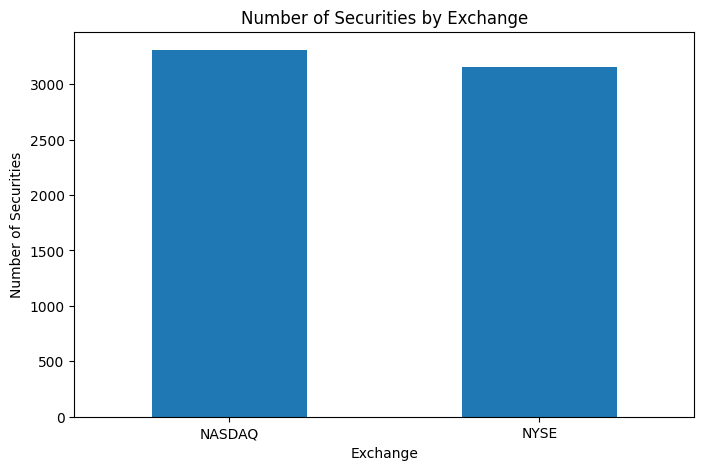

In [12]:
# Explore Stock Exchanges

exchange_counts = stocks['exchange'].value_counts()

print("Number of Securities by Exchange:")
print(exchange_counts)

plt.figure(figsize=(8, 5))
exchange_counts.plot(kind='bar')

plt.title('Number of Securities by Exchange')
plt.xlabel('Exchange')
plt.ylabel('Number of Securities')
plt.xticks(rotation=0)
plt.show()

**Step 14: Show the Exact Exchange Counts**

In [23]:
# Display Exact Exchange Counts

print(exchange_counts)

exchange
NASDAQ    3308
NYSE      3152
Name: count, dtype: int64


**Step 15: Answer Part 4.1 — Stock Exchanges**

### Stock Exchanges

The dataset contains securities from two exchanges: NASDAQ and NYSE.

- NASDAQ has 3,308 securities.
- NYSE has 3,152 securities.

NASDAQ has slightly more securities than NYSE in this dataset. The bar chart also shows that the number of securities on the two exchanges is fairly close.

**Step 16: Part 4.2 — Explore Sectors**

Number of Securities by Sector:
sector
FINANCE                  1022
CONSUMER SERVICES         796
HEALTH CARE               784
TECHNOLOGY                607
CAPITAL GOODS             352
ENERGY                    286
PUBLIC UTILITIES          273
BASIC INDUSTRIES          272
CONSUMER NON-DURABLES     224
CONSUMER DURABLES         144
MISCELLANEOUS             139
TRANSPORTATION            120
SECTOR                      1
Name: count, dtype: int64

Missing Sector Information:
1440


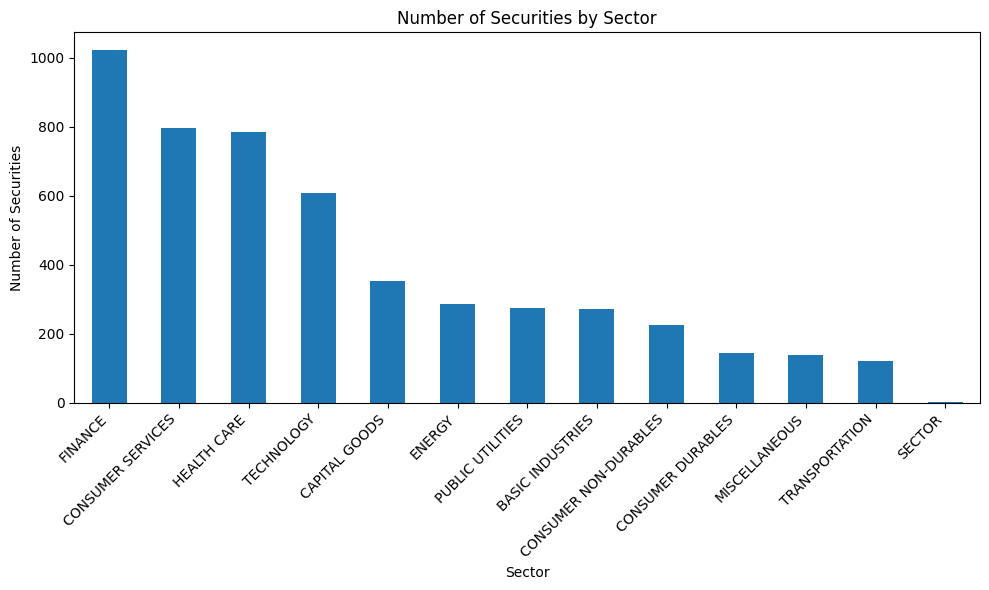

In [24]:
# Explore Sectors

sector_counts = stocks['sector'].value_counts()

print("Number of Securities by Sector:")
print(sector_counts)

print("\nMissing Sector Information:")
print(stocks['sector'].isnull().sum())

plt.figure(figsize=(10, 6))
sector_counts.plot(kind='bar')

plt.title('Number of Securities by Sector')
plt.xlabel('Sector')
plt.ylabel('Number of Securities')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Step 17: Answer Part 4.2 — Sectors**

### Sectors

Finance has the most securities in the dataset with 1,022, followed by Consumer Services with 796 and Health Care with 784.

There are 1,440 securities with missing sector information. This does not necessarily mean the records are incorrect. Some securities may not have been assigned to a sector, or the sector information may not have been available when the dataset was created.

I also noticed one unusual category named `SECTOR`. Since an unusual value is not automatically an error, I kept it in the dataset for now rather than removing it without further evidence.

**Step 18: Part 5 — Explore Numerical Data**

In [25]:
# Explore Numerical Data

numerical_columns = ['open', 'high', 'low', 'close', 'volume']

# Descriptive statistics
display(stock_prices[numerical_columns].describe())

# Median values
print("Median Values:")
print(stock_prices[numerical_columns].median())

,open,high,low,close,volume
count,2.097389e+07,2.097389e+07,2.097389e+07,2.097389e+07,2.097389e+07
mean,7.605823e+01,7.803857e+01,7.422064e+01,7.611403e+01,1.227043e+06
std,2.849639e+03,2.997937e+03,2.746059e+03,2.870159e+03,1.316686e+07
min,4.000000e-04,4.000000e-04,1.000000e-04,2.000000e-04,1.000000e+00
25%,7.500000e+00,7.630000e+00,7.360000e+00,7.500000e+00,2.210000e+04
50%,1.545000e+01,1.566000e+01,1.524000e+01,1.545000e+01,1.260000e+05
75%,2.972000e+01,3.010000e+01,2.928000e+01,2.972000e+01,6.074000e+05
max,2.034000e+06,2.070000e+06,1.440000e+06,1.779750e+06,4.483504e+09


Median Values:
open          15.45
high          15.66
low           15.24
close         15.45
volume    126000.00
dtype: float64


**Step 19: Answer Part 5 Questions**

## Part 5: Numerical Data Findings

1. **What is the mean closing price?**  
The mean closing price is approximately $76.11.

2. **What is the median closing price?**  
The median closing price is $15.45.

3. **How different are the mean and median?**  
The mean is much higher than the median. The difference is about $60.66.

4. **Which variable has the largest standard deviation?**  
Volume has the largest standard deviation, at approximately 13.17 million.

5. **Which variables contain very large maximum values?**  
Several variables have very large maximum values. The closing price reaches about $1.78 million, while trading volume reaches about 4.48 billion.

6. **What might the difference between the mean and median tell you about the data?**  
The large difference suggests that the data is right-skewed. A small number of extremely high values are pulling the mean upward. These unusual values should be investigated before deciding whether they are errors.

**Step 20: Part 6.1 — Investigate Highest Closing Prices**

In [26]:
# Investigate Highest Closing Prices

highest_close = stock_prices.nlargest(
    10, 'close'
)[['ticker', 'date', 'open', 'high', 'low', 'close', 'volume']]

display(highest_close)

,ticker,date,open,high,low,close,volume
12146443,SCON,2000-02-28,1395000.000,1797750.0,1368000.00,1779750.0,400
12146459,SCON,2000-02-29,2034000.000,2070000.0,1440000.00,1595250.0,400
12146546,SCON,2000-03-13,900000.000,1404000.0,861750.00,1363500.0,300
17889354,CODA,2001-02-05,1354500.000,1736700.0,1354500.00,1354500.0,34
2444619,TVIX,2013-02-26,1375000.000,1542500.0,1300000.00,1347500.0,100
12146480,SCON,2000-03-02,1120500.000,1368000.0,1098280.75,1261125.0,200
12146437,SCON,2000-02-25,873561.625,1369125.0,873000.00,1215000.0,200
17107201,TOPS,2016-08-01,783000.000,1276200.0,783000.00,1189800.0,100
12146465,SCON,2000-03-01,1368000.000,1512000.0,1107000.00,1134000.0,300
12146562,SCON,2000-03-14,1352250.000,1354500.0,1080000.00,1111500.0,100


**Step 21: Answer Part 6.1**

### Highest Closing Prices

The highest closing price in the dataset belongs to SCON, with a close of $1,779,750 on February 28, 2000. Several other very high closing prices also belong to SCON. CODA, TVIX, and TOPS also appear among the highest values.

The trading volumes for these observations are very low, ranging from only a few dozen to a few hundred shares. This makes the values look unusual compared with the rest of the dataset.

However, I cannot conclude that these observations are errors just because they are extremely high. They may be related to historical stock adjustments, corporate actions, or characteristics of the securities. I kept these observations rather than deleting them without enough evidence.

**Step 22: Part 6.2 — Investigate Highest Adjusted Closing Prices**

In [27]:
# Investigate Highest Adjusted Closing Prices

highest_adj_close = stock_prices.nlargest(
    10, 'adj_close'
)[['ticker', 'date', 'close', 'adj_close', 'volume']]

display(highest_adj_close)

,ticker,date,close,adj_close,volume
6174033,AAN,1987-02-27,1.296296,1.894962e+19,346900
6174039,AAN,1987-03-10,1.296296,1.894962e+19,20200
6174040,AAN,1987-03-11,1.296296,1.894962e+19,18900
6174041,AAN,1987-03-12,1.296296,1.894962e+19,27000
6174044,AAN,1987-03-17,1.296296,1.894962e+19,31000
6174045,AAN,1987-03-18,1.296296,1.894962e+19,272700
6174046,AAN,1987-03-19,1.296296,1.894962e+19,4000
6174049,AAN,1987-03-25,1.296296,1.894962e+19,184900
6174051,AAN,1987-03-27,1.287037,1.881428e+19,205200
6174050,AAN,1987-03-26,1.268519,1.854356e+19,20200


**Step 23: Answer Part 6.2**

### Adjusted Closing Price

The largest adjusted closing prices are associated with ticker AAN. The values appear mainly in February and March 1987.

These observations are extremely unusual. For example, the regular closing price is around $1.30, while the adjusted closing price is approximately 1.89 × 10¹⁹. This is a very large difference between the two values.

The adjusted closing values may be affected by historical adjustments or another issue in the dataset. However, the results alone are not enough to prove that they are errors. For this reason, I did not automatically delete these observations. They would need further investigation before making a final cleaning decision.

**Step 24: Part 7.1 — Closing Price Histogram**

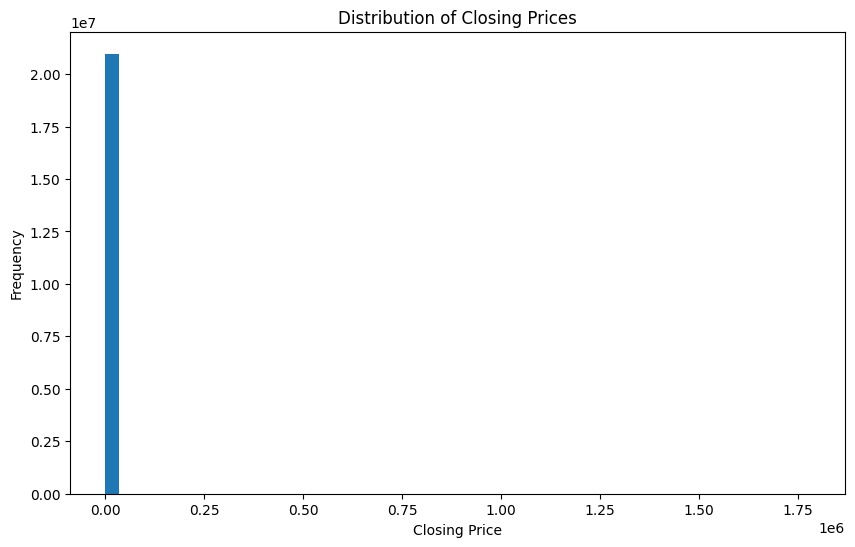

In [29]:
# Closing Price Histogram

plt.figure(figsize=(10, 6))
plt.hist(stock_prices['close'], bins=50)

plt.title('Distribution of Closing Prices')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')
plt.show()

**Step 25: Volume Histogram**

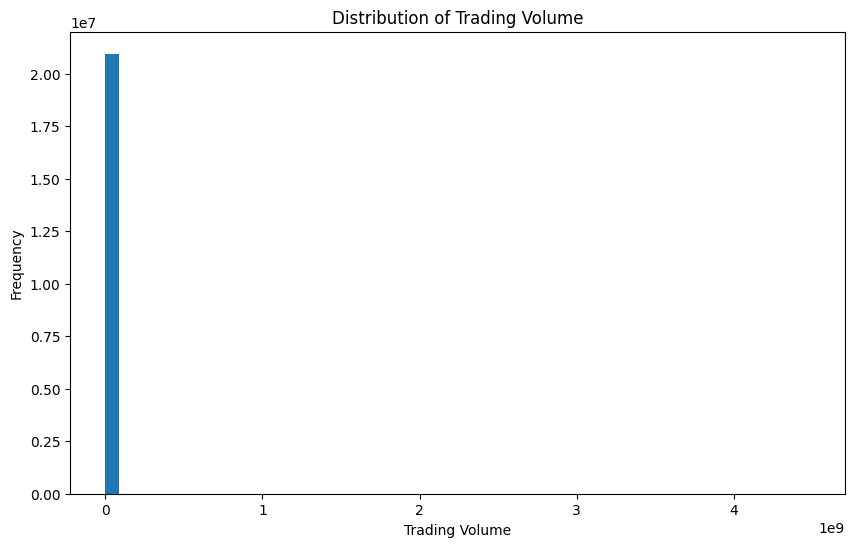

In [30]:
# Volume Histogram

plt.figure(figsize=(10, 6))
plt.hist(stock_prices['volume'], bins=50)

plt.title('Distribution of Trading Volume')
plt.xlabel('Trading Volume')
plt.ylabel('Frequency')
plt.show()

**Step 26: Closing Price Boxplot**

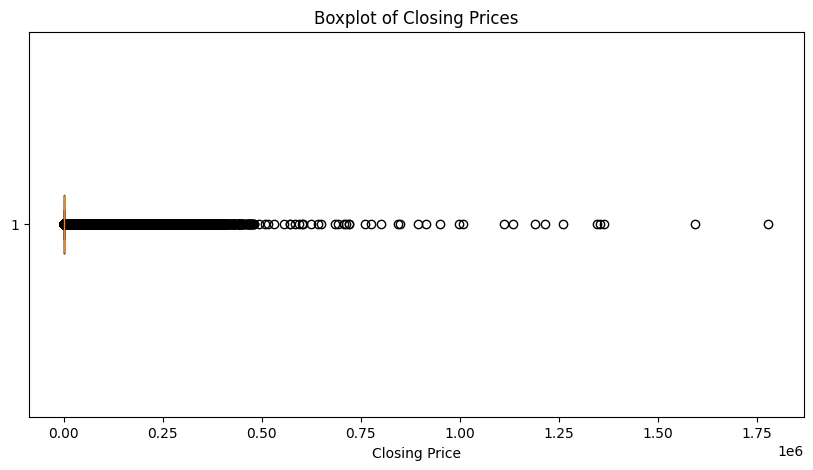

In [31]:
# Closing Price Boxplot

plt.figure(figsize=(10, 5))
plt.boxplot(stock_prices['close'], vert=False)

plt.title('Boxplot of Closing Prices')
plt.xlabel('Closing Price')
plt.show()

**Step 27: Volume Boxplot**

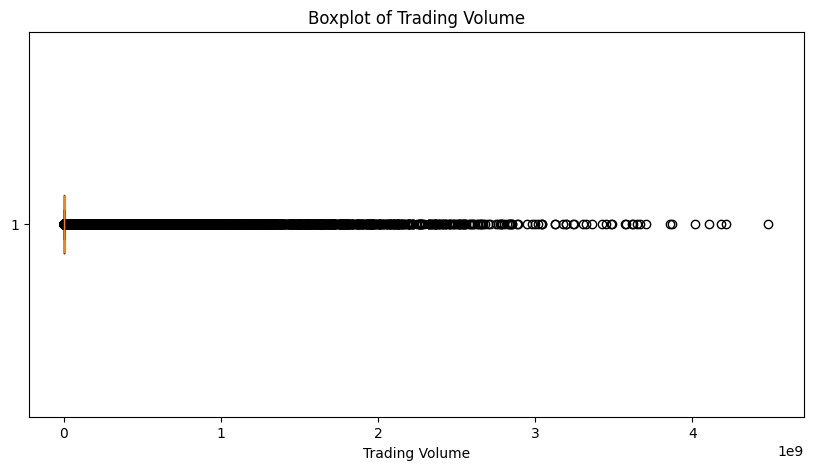

In [32]:
# Volume Boxplot

plt.figure(figsize=(10, 5))
plt.boxplot(stock_prices['volume'], vert=False)

plt.title('Boxplot of Trading Volume')
plt.xlabel('Trading Volume')
plt.show()

**Step 28: Answer Part 7 Visualization Questions**

## Visualization Findings

1. **What does the distribution of closing prices look like?**  
Most closing prices are concentrated at lower values, with a small number of extremely high prices.

2. **Is it approximately symmetric or skewed?**  
The closing price distribution is strongly right-skewed.

3. **Are there extreme values?**  
Yes. The histogram and boxplot show several extreme high closing prices.

4. **What does the volume distribution look like?**  
Trading volume is also strongly right-skewed. Most observations have lower volumes, while a small number have extremely high trading volumes.

5. **What do the boxplots tell you about potential outliers?**  
Both boxplots show many potential outliers on the high end. These values are unusual, but they should not automatically be considered errors.

6. **How do the visualizations compare with the descriptive statistics?**  
The visualizations support the descriptive statistics. The large maximum values and the differences between the mean and median are consistent with the strong right-skew and extreme values shown in the charts.

**Step 29: Part 8 — Choose One Stock**

Number of AAPL Records: 9507
Earliest AAPL Date: 1980-12-12 00:00:00
Latest AAPL Date: 2018-08-24 00:00:00


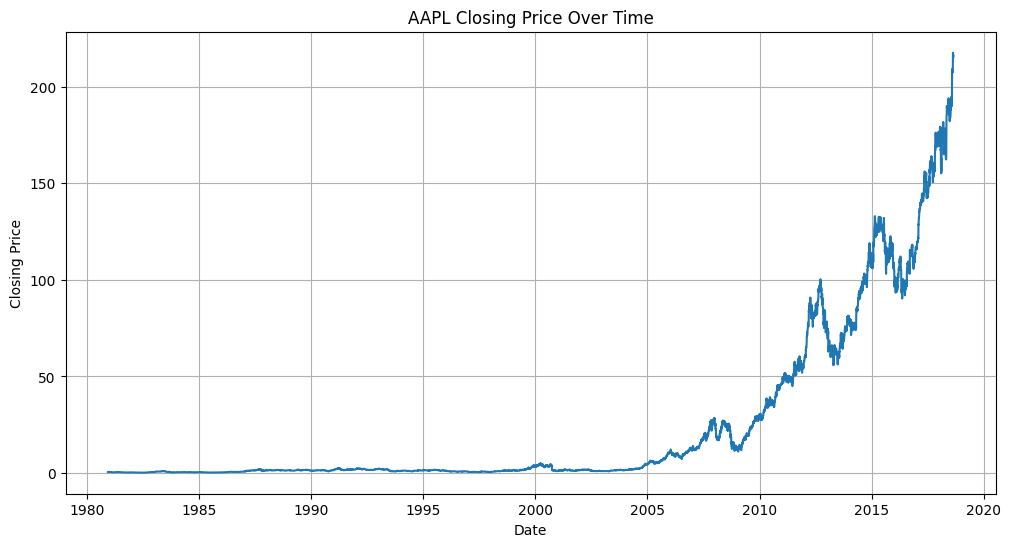

In [33]:
# Explore Apple (AAPL) Stock Over Time

selected_stock = stock_prices[stock_prices['ticker'] == 'AAPL'].copy()

print("Number of AAPL Records:", len(selected_stock))
print("Earliest AAPL Date:", selected_stock['date'].min())
print("Latest AAPL Date:", selected_stock['date'].max())

plt.figure(figsize=(12, 6))
plt.plot(selected_stock['date'], selected_stock['close'])

plt.title('AAPL Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True)
plt.show()

**Step 30: Check AAPL Details**

In [34]:
# Check AAPL Data Details

print("Number of AAPL Records:", len(selected_stock))
print("Earliest AAPL Date:", selected_stock['date'].min())
print("Latest AAPL Date:", selected_stock['date'].max())

print("\nLowest Closing Price:")
display(selected_stock.nsmallest(1, 'close')[['date', 'close']])

print("\nHighest Closing Price:")
display(selected_stock.nlargest(1, 'close')[['date', 'close']])

Number of AAPL Records: 9507
Earliest AAPL Date: 1980-12-12 00:00:00
Latest AAPL Date: 2018-08-24 00:00:00

Lowest Closing Price:


,date,close
5493,1982-07-08,0.196429



Highest Closing Price:


,date,close
100490,2018-08-17,217.580002


**Step 31: Answer Part 8 Questions**

## Part 8: Exploring AAPL Stock

1. **Which ticker did you choose?**  
I chose AAPL (Apple) for this analysis.

2. **How does its price change over time?**  
AAPL's closing price stayed relatively low during the earlier years of the dataset. The price began to grow more strongly after the mid-2000s and increased significantly in later years.

3. **Are there periods of unusually high or low prices?**  
Yes. The lowest closing price was approximately $0.20 on July 8, 1982. The highest closing price was approximately $217.58 on August 17, 2018. The chart also shows several periods of growth and decline along the way.

4. **Are there gaps in the available data?**  
The dataset contains 9,507 AAPL records from December 12, 1980 to August 24, 2018. The line chart appears generally continuous across this period, although stock market data naturally does not include every calendar day because markets are closed on weekends and holidays.

5. **What additional information would you need to explain major price changes?**  
To better explain major price changes, I would need information about company events, product releases, financial results, stock splits, economic conditions, and major market events.

**Step 32: Final Summary and Future Hypotheses**

## Final Summary

This project explored historical stock market data from 1970 to 2018. The stock information dataset contained 6,460 securities, while the stock price dataset contained more than 2.1 million daily price records. The data included information about stock exchanges, sectors, prices, trading volume, and dates.

During the data-quality check, I found 1,440 missing values in both the sector and industry columns. These records were kept because missing category information does not automatically mean the records are incorrect. One incomplete stock price record was removed because it was missing the date, high price, and volume. No duplicate rows or duplicate ticker and date combinations were found.

The numerical analysis showed that stock prices and trading volumes are strongly right-skewed. The mean closing price was about $76.11, while the median was only $15.45. Several extremely high values were found, including unusual closing prices for SCON and extremely large adjusted closing prices for AAN. These observations were investigated but not automatically removed because unusual values are not necessarily errors.

The histograms and boxplots confirmed that both closing prices and trading volumes contain many extreme high values. I also explored Apple (AAPL), which had 9,507 records from December 12, 1980 to August 24, 2018. Its closing price showed strong long-term growth, especially after the mid-2000s, although there were also periods of decline.

### Future Questions / Hypotheses

1. Does trading volume increase during periods when stock prices experience large changes?

2. Do stocks from different sectors show different levels of price volatility?